In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import os

os.makedirs("../outputs",exist_ok=True)
os.makedirs("../reports/charts",exist_ok=True)

In [2]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

In [3]:
nav['date'] = pd.to_datetime(
    nav['date']
)

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [4]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = nav.groupby(
    'amfi_code'
)['nav'].pct_change()

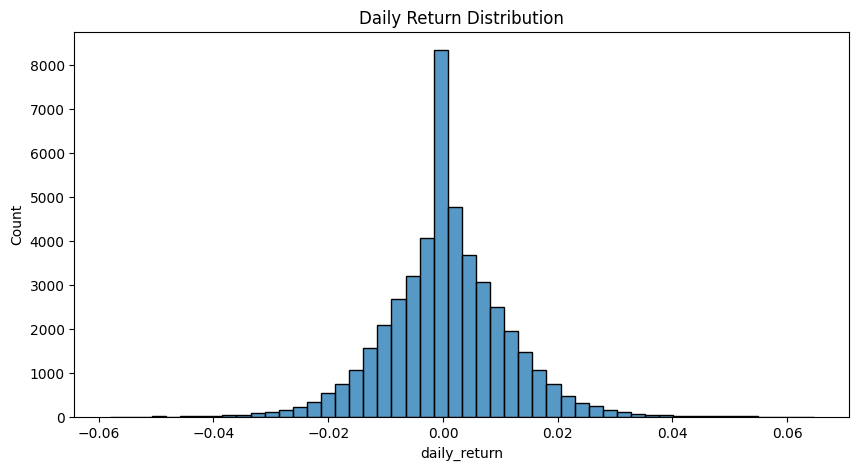

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [6]:
cagr_data = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==code
    ].sort_values('date')

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp.iloc[-1]['date']
        -
        temp.iloc[0]['date']
    ).days/365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
    )-1

    cagr_data.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf = 0.065

sharpe_data = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==code
    ]

    mean_return = temp[
        'daily_return'
    ].mean()

    std_return = temp[
        'daily_return'
    ].std()

    sharpe = (
        (mean_return-rf/252)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_data.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

In [8]:
sortino_data = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==code
    ]

    downside = temp[
        temp['daily_return'] < 0
    ]['daily_return']

    downside_std = downside.std()

    mean_return = temp[
        'daily_return'
    ].mean()

    sortino = (
        (mean_return-rf/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_data.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [9]:
nifty = benchmark[
    benchmark['index_name']
    ==
    'NIFTY50'
].copy()

In [10]:
nifty['benchmark_return'] = nifty[
    'close_value'
].pct_change()

In [11]:
alpha_beta = []

for code in nav[
    'amfi_code'
].unique():

    fund = nav[
        nav['amfi_code']==code
    ]

    merged = pd.merge(
        fund,
        nifty[
            [
            'date',
            'benchmark_return'
            ]
        ],
        on='date'
    )

    merged = merged.dropna()

    if len(merged)<20:
        continue

    slope, intercept, _, _, _ = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [code,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

In [12]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [13]:
drawdown_data = []

for code in nav[
    'amfi_code'
].unique():

    temp = nav[
        nav['amfi_code']==code
    ].copy()

    temp['running_max'] = temp[
        'nav'
    ].cummax()

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
    )-1

    max_dd = temp[
        'drawdown'
    ].min()

    drawdown_data.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

In [14]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

In [15]:
scorecard['cagr_rank'] = \
scorecard['cagr'].rank(
    ascending=False
)

scorecard['sharpe_rank'] = \
scorecard['sharpe_ratio'].rank(
    ascending=False
)

scorecard['alpha_rank'] = \
scorecard['alpha'].rank(
    ascending=False
)

scorecard['dd_rank'] = \
scorecard['max_drawdown'].rank(
    ascending=False
)

In [16]:
scorecard['score'] = (
0.30*scorecard['cagr_rank']
+
0.25*scorecard['sharpe_rank']
+
0.20*scorecard['alpha_rank']
+
0.10*scorecard['dd_rank']
)

In [17]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

In [18]:
top5 = scorecard.sort_values(
    'score'
).head(5)

top5

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,score
34,148567,0.309499,1.448291,0.271150,-0.028133,-0.112657,5.0,1.0,7.0,8.0,3.95
30,120843,0.308833,1.306744,0.272784,-0.008737,-0.129740,6.0,2.0,5.0,13.0,4.60
25,120505,0.328016,1.180101,0.293014,-0.017391,-0.181885,1.0,5.0,3.0,25.0,4.65
36,148569,0.319245,1.234930,0.283473,-0.010201,-0.163967,4.0,3.0,4.0,21.0,4.85
2,100033,0.300997,1.093699,0.272343,-0.011200,-0.162172,7.0,7.0,6.0,20.0,7.05
